In [8]:

import pandas as pd
import numpy as np


1. SYNTHETIC TELEMETRY DATA GENERATION

In [14]:
def generate_satellite_telemetry(n_minutes=2880):  # 48 hours of orbit data
    np.random.seed(42)
    timestamps = pd.date_range(start="2026-09-19 00:00:00", periods=n_minutes, freq="min")

    # 90-minute orbital periodicity (~16 orbits/day)
    orbit_period = 90
    minute_of_orbit = np.array([i % orbit_period for i in range(n_minutes)])
    is_sunlit = minute_of_orbit < 60  # 60 mins sun, 30 mins eclipse

    # Base Telemetry Generation
    solar_output = np.where(is_sunlit, 180 + 10 * np.sin(minute_of_orbit / 10) + np.random.normal(0, 2, n_minutes), 0.0)
    power_draw = 130 + np.random.normal(0, 3, n_minutes)

    # Battery Dynamics
    battery_charge_current = np.where(is_sunlit, (solar_output - power_draw) / 28.0, 0.0)
    battery_discharge_current = np.where(~is_sunlit, power_draw / 28.0, 0.0)
    battery_current = battery_charge_current - battery_discharge_current + np.random.normal(0, 0.2, n_minutes)

    battery_voltage = 28.0 + 2.5 * np.sin(minute_of_orbit / 15) + np.random.normal(0, 0.1, n_minutes)
    battery_temp = np.where(is_sunlit, 22.0 + 4.0 * np.sin(minute_of_orbit / 20), 12.0 - 2.0 * np.cos(minute_of_orbit / 15)) + np.random.normal(0, 0.3, n_minutes)

    gyro_x = np.random.normal(0.0, 0.02, n_minutes)
    gyro_y = np.random.normal(0.0, 0.02, n_minutes)
    gyro_z = np.random.normal(0.05, 0.01, n_minutes)  # nominal spin
    signal_strength = -65.0 + 3.0 * np.cos(minute_of_orbit / 12) + np.random.normal(0, 1.0, n_minutes)

    df = pd.DataFrame({
        "Timestamp": timestamps,
        "Temperature_C": battery_temp,
        "Battery_Voltage_V": battery_voltage,
        "Battery_Current_A": battery_current,
        "Power_Consumption_W": power_draw,
        "Solar_Panel_Output_W": solar_output,
        "Gyro_X": gyro_x,
        "Gyro_Y": gyro_y,
        "Gyro_Z": gyro_z,
        "Signal_Strength_dBm": signal_strength,
        "Ground_Truth": 0  # 0: Nominal, 1: Anomaly
    })

    # Injecting Data Quality Imperfections (Missing values)
    df.loc[350:354, "Solar_Panel_Output_W"] = np.nan
    df.loc[1200:1203, "Signal_Strength_dBm"] = np.nan

    # INJECT ANOMALY 1: Assignment Scenario (Battery Thermal Runaway / Fault)
    df.loc[2100:2140, "Temperature_C"] += np.linspace(5, 35, 41)
    df.loc[2100:2140, "Battery_Voltage_V"] -= np.linspace(1, 8, 41)
    df.loc[2100:2140, "Power_Consumption_W"] += np.linspace(20, 90, 41)
    df.loc[2100:2140, "Ground_Truth"] = 1

    return df

2. DATA CLEANSING & FEATURE ENGINEERING

In [15]:
def cleanse_and_engineer(df):
    clean_df = df.copy()

    # Missing Value Handling: Forward-Fill + Backward-Fill
    clean_df = clean_df.ffill().bfill()

    # Feature Engineering (Rates of change)
    clean_df["dT_dt"] = clean_df["Temperature_C"].diff().fillna(0)
    clean_df["dV_dt"] = clean_df["Battery_Voltage_V"].diff().fillna(0)
    clean_df["Power_Delta"] = clean_df["Solar_Panel_Output_W"] - clean_df["Power_Consumption_W"]

    # Gyroscope magnitudes
    clean_df["Gyro_Magnitude"] = np.sqrt(clean_df["Gyro_X"]**2 + clean_df["Gyro_Y"]**2 + clean_df["Gyro_Z"]**2)
    clean_df["Gyro_Rolling_Std"] = clean_df["Gyro_Magnitude"].rolling(window=10, min_periods=1).std().fillna(0)

    return clean_df

EXECUTION SCRIPT

In [17]:
if __name__ == "__main__":
    print("Generating raw satellite telemetry...")
    raw_df = generate_satellite_telemetry()

    print("\nProcessing data and engineering features...")
    processed_df = cleanse_and_engineer(raw_df)

    # Print the first 5 rows to the console
    print("\n--- First 5 Rows of Processed Data ---")
    print(processed_df.head())

    # Print missing value check (should be 0 because we cleansed it)
    print("\n--- Missing Values Count ---")
    print(processed_df.isnull().sum())

    # Save to a CSV file so you can inspect the full dataset manually
    csv_filename = "processed_telemetry.csv"
    processed_df.to_csv(csv_filename, index=False)
    print(f"\nFull dataset saved successfully to '{csv_filename}'. You can open this in PyCharm or Excel.")

Generating raw satellite telemetry...

Processing data and engineering features...

--- First 5 Rows of Processed Data ---
            Timestamp  Temperature_C  Battery_Voltage_V  Battery_Current_A  \
0 2026-09-19 00:00:00      22.394903          28.161704           2.066890   
1 2026-09-19 00:01:00      21.327318          28.089501           2.142040   
2 2026-09-19 00:02:00      22.032509          28.446683           1.771687   
3 2026-09-19 00:03:00      22.323063          28.515159           1.670044   
4 2026-09-19 00:04:00      22.548763          28.684013           2.223884   

   Power_Consumption_W  Solar_Panel_Output_W    Gyro_X    Gyro_Y    Gyro_Z  \
0           123.285306            180.993428 -0.001085  0.004911  0.053461   
1           123.637900            180.721806 -0.025938  0.011171  0.042235   
2           128.179404            183.282070  0.017416  0.011814  0.057464   
3           131.373060            186.001262  0.014870 -0.028180  0.052653   
4           121.75

SUBPLOTS (10x1)


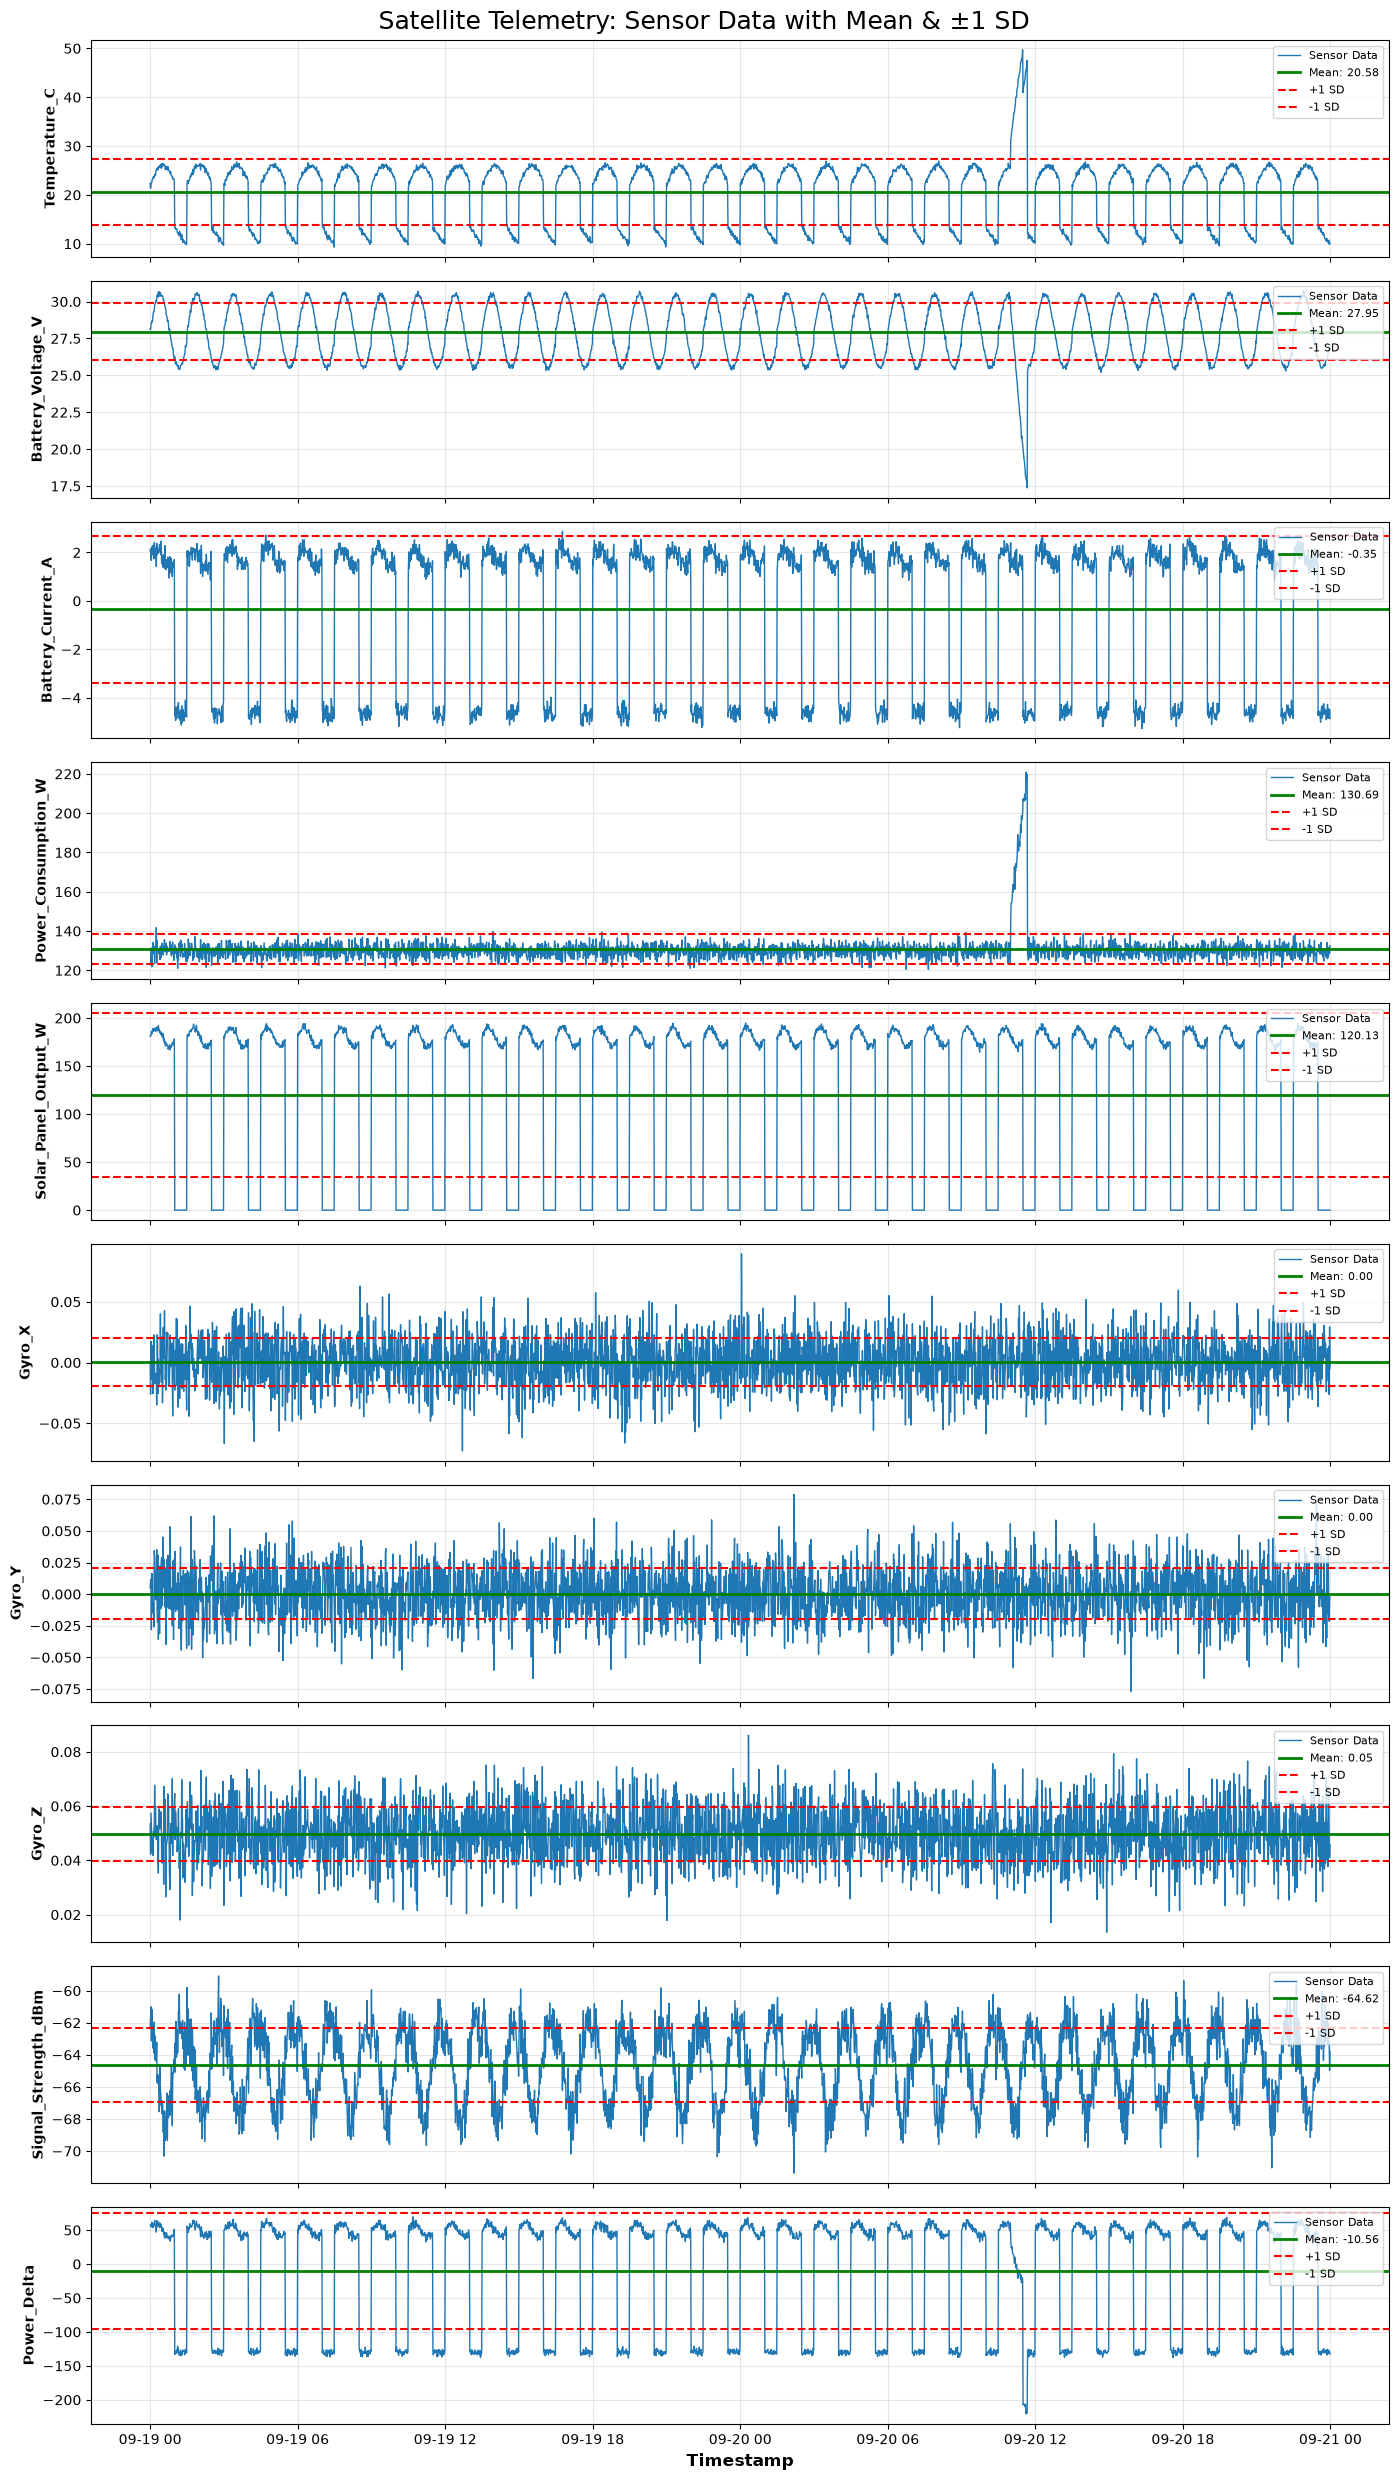

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset saved from the previous step
# parse_dates ensures the Timestamp column is formatted as actual time, not plain text
df = pd.read_csv('processed_telemetry.csv', parse_dates=['Timestamp'])

# 2. Define the 10 features to plot (9 raw sensors + 1 core power feature for the 10th slot)
features = [
    'Temperature_C',
    'Battery_Voltage_V',
    'Battery_Current_A',
    'Power_Consumption_W',
    'Solar_Panel_Output_W',
    'Gyro_X',
    'Gyro_Y',
    'Gyro_Z',
    'Signal_Strength_dBm',
    'Power_Delta'
]

# 3. Set up the 10x1 subplot grid (width=14, height=25 for readability)
fig, axes = plt.subplots(nrows=10, ncols=1, figsize=(14, 25), sharex=True)
fig.suptitle('Satellite Telemetry: Sensor Data with Mean & ±1 SD', fontsize=18, y=0.99)

# 4. Loop through each feature and plot it on its corresponding axis
for i, feature in enumerate(features):
    ax = axes[i]

    # Calculate statistics
    mean_val = df[feature].mean()
    std_val = df[feature].std()

    # Plot the sensor data timeline
    ax.plot(df['Timestamp'], df[feature], color='#1f77b4', linewidth=1, label='Sensor Data')

    # Draw horizontal statistical lines
    ax.axhline(mean_val, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axhline(mean_val + std_val, color='red', linestyle='--', linewidth=1.5, label='+1 SD')
    ax.axhline(mean_val - std_val, color='red', linestyle='--', linewidth=1.5, label='-1 SD')

    # Format labels, grid, and legend
    ax.set_ylabel(feature, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# 5. Label the common X-axis at the very bottom
axes[-1].set_xlabel('Timestamp', fontsize=12, fontweight='bold')

# Adjust layout to prevent overlapping text and display the window
plt.tight_layout()
plt.show()

SUBPLOTS (10X2)

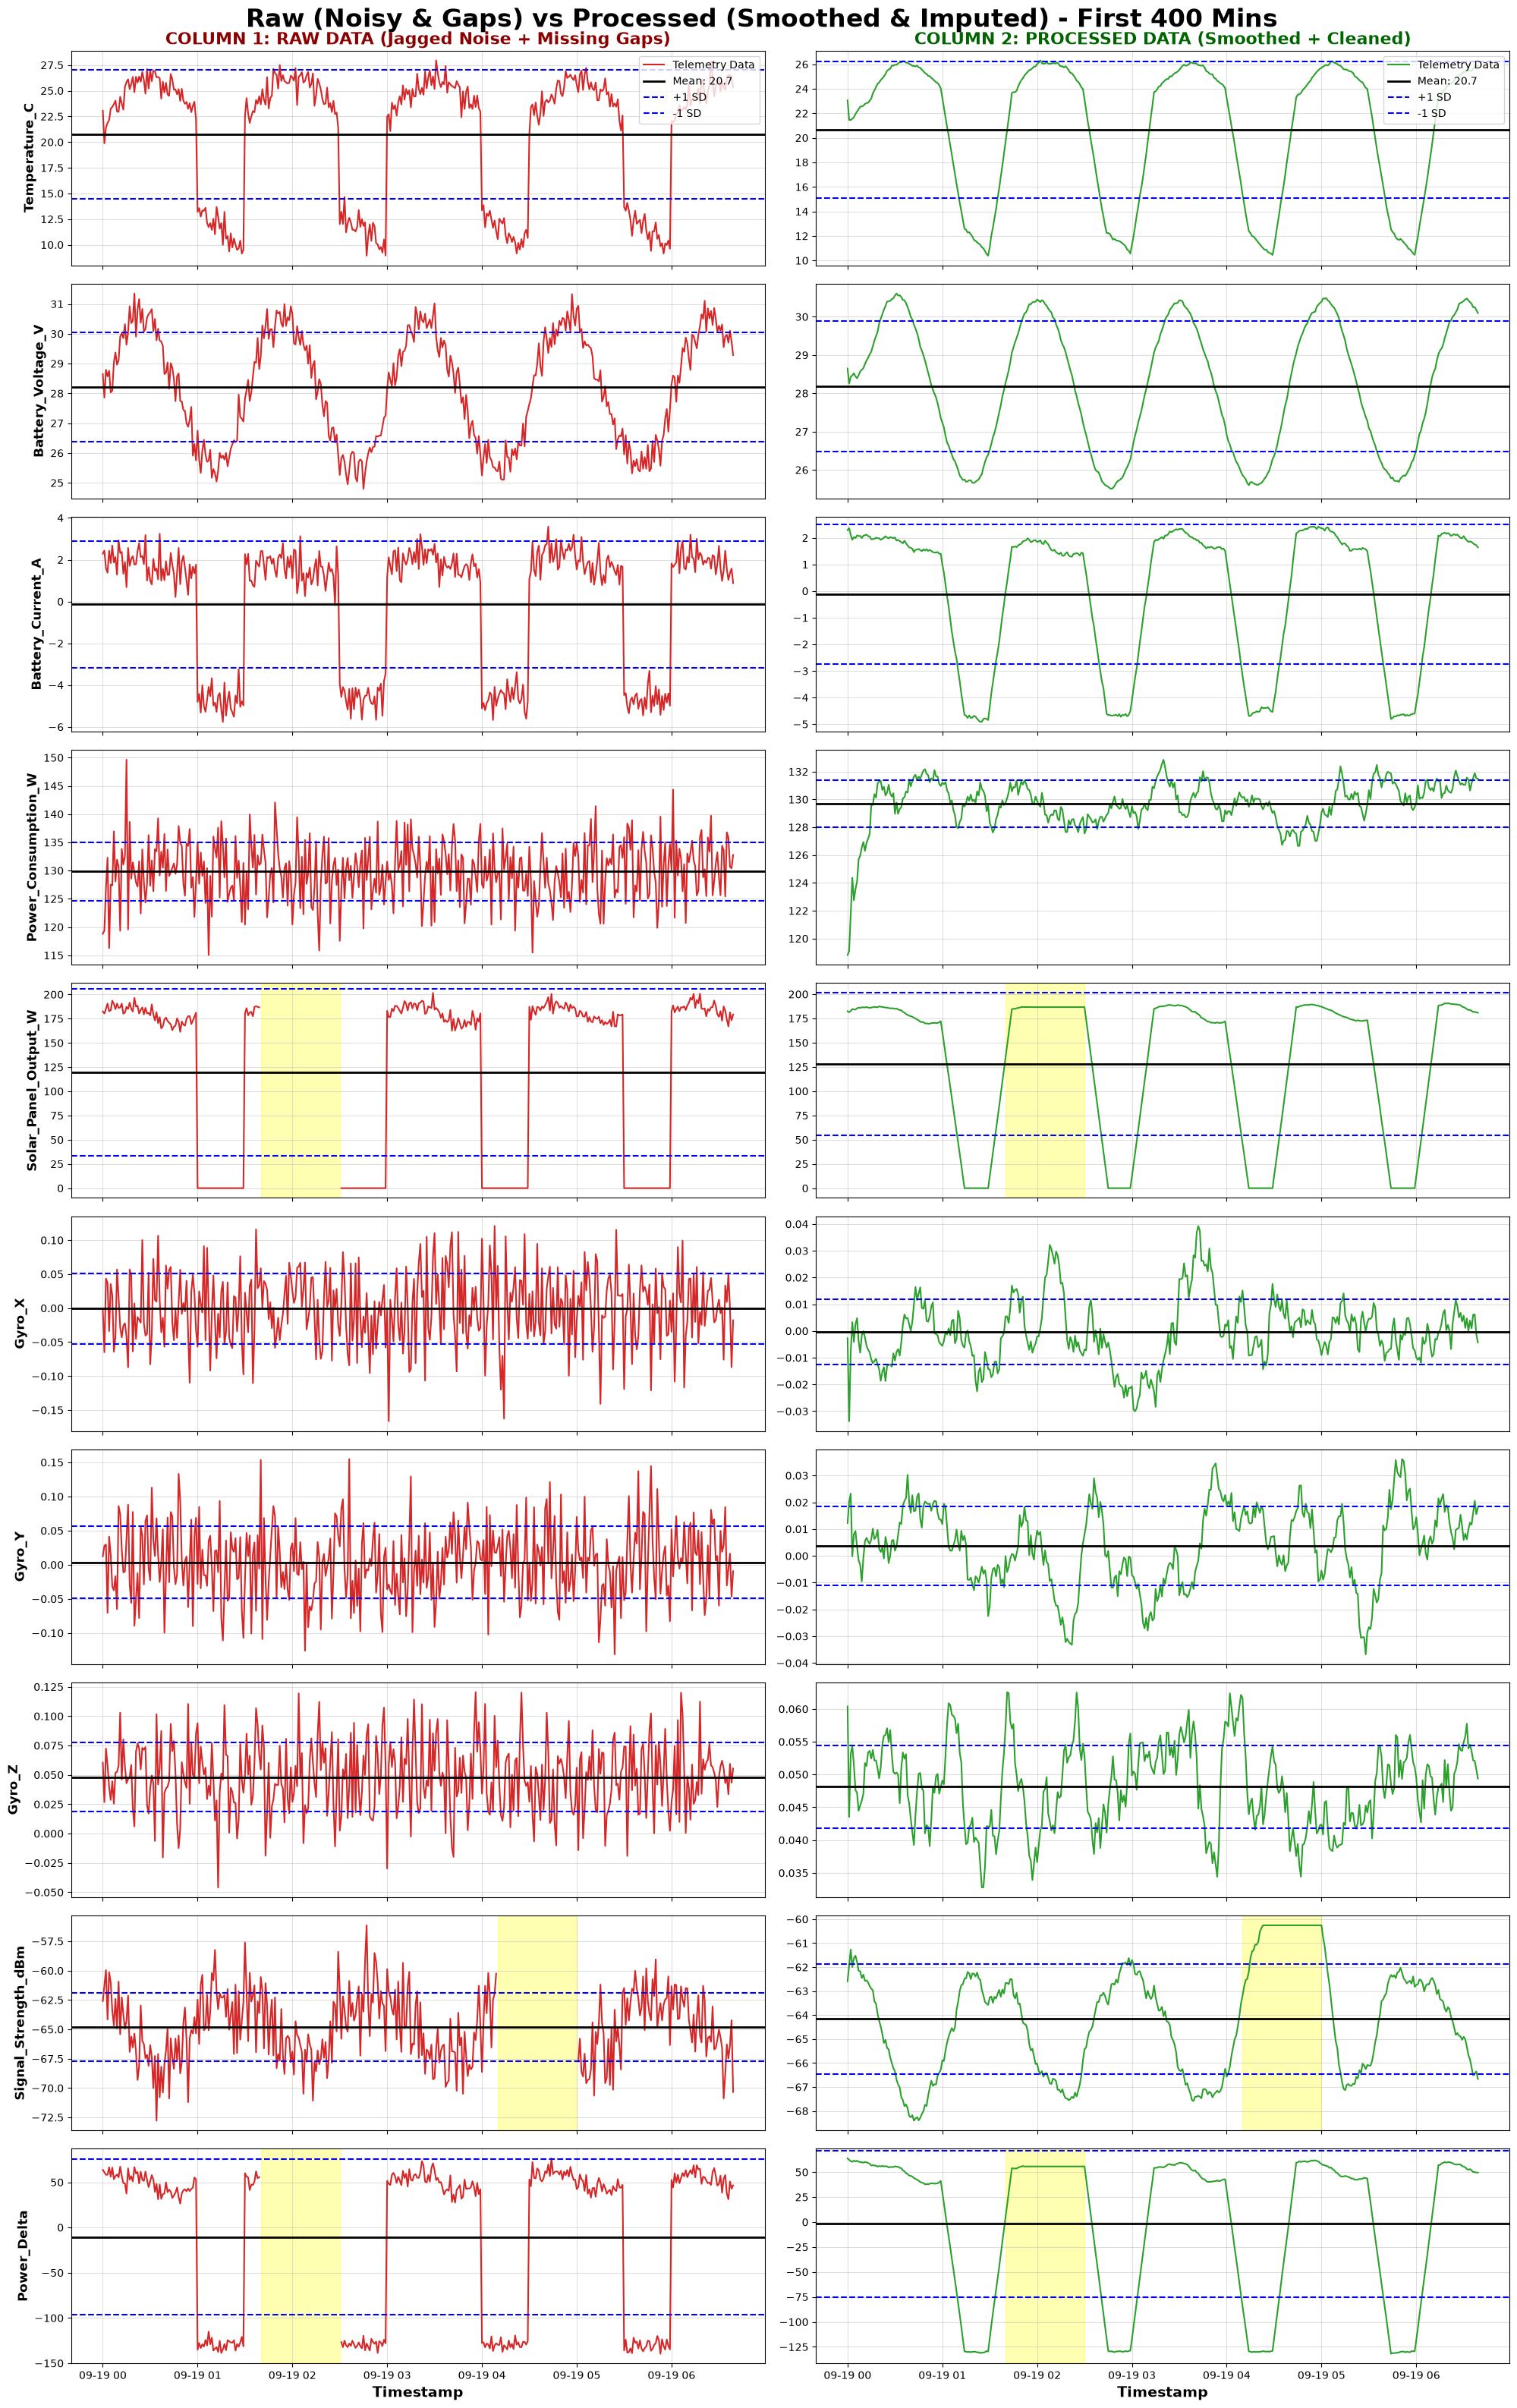

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. GENERATE RAW AND PROCESSED DATA (WITH NOISE REDUCTION)
# =====================================================================
def get_comparison_data():
    np.random.seed(42)
    n_minutes = 2880 # 48 hours
    timestamps = pd.date_range(start="2026-09-19 00:00:00", periods=n_minutes, freq="min")
    minute_of_orbit = np.array([i % 90 for i in range(n_minutes)])
    is_sunlit = minute_of_orbit < 60

    # Base features with intentionally high noise for visibility
    solar_output = np.where(is_sunlit, 180 + 10 * np.sin(minute_of_orbit / 10) + np.random.normal(0, 5, n_minutes), 0.0)
    power_draw = 130 + np.random.normal(0, 5, n_minutes)
    battery_current = np.where(is_sunlit, (solar_output - power_draw) / 28.0, 0.0) - np.where(~is_sunlit, power_draw / 28.0, 0.0) + np.random.normal(0, 0.5, n_minutes)
    battery_voltage = 28.0 + 2.5 * np.sin(minute_of_orbit / 15) + np.random.normal(0, 0.4, n_minutes)
    battery_temp = np.where(is_sunlit, 22.0 + 4.0 * np.sin(minute_of_orbit / 20), 12.0 - 2.0 * np.cos(minute_of_orbit / 15)) + np.random.normal(0, 0.8, n_minutes)
    gyro_x = np.random.normal(0.0, 0.05, n_minutes)
    gyro_y = np.random.normal(0.0, 0.05, n_minutes)
    gyro_z = np.random.normal(0.05, 0.03, n_minutes)
    signal_strength = -65.0 + 3.0 * np.cos(minute_of_orbit / 12) + np.random.normal(0, 2.0, n_minutes)

    raw_df = pd.DataFrame({
        "Timestamp": timestamps,
        "Temperature_C": battery_temp,
        "Battery_Voltage_V": battery_voltage,
        "Battery_Current_A": battery_current,
        "Power_Consumption_W": power_draw,
        "Solar_Panel_Output_W": solar_output,
        "Gyro_X": gyro_x,
        "Gyro_Y": gyro_y,
        "Gyro_Z": gyro_z,
        "Signal_Strength_dBm": signal_strength
    })

    # Inject missing data gaps
    raw_df.loc[100:150, "Solar_Panel_Output_W"] = np.nan
    raw_df.loc[250:300, "Signal_Strength_dBm"] = np.nan
    raw_df["Power_Delta"] = raw_df["Solar_Panel_Output_W"] - raw_df["Power_Consumption_W"]

    # --- PROCESSED DATA ---
    processed_df = raw_df.copy()

    # Step 1: Fill missing values
    processed_df = processed_df.ffill().bfill()

    # Step 2: Apply Noise Reduction (15-minute rolling average)
    features_to_smooth = [col for col in processed_df.columns if col != 'Timestamp']
    for col in features_to_smooth:
        processed_df[col] = processed_df[col].rolling(window=15, min_periods=1).mean()

    return raw_df, processed_df

raw_df, processed_df = get_comparison_data()

# Zoom in on the first 400 minutes so the noise/smoothing is visually obvious
zoom_limit = 400
raw_df_zoomed = raw_df.iloc[:zoom_limit]
processed_df_zoomed = processed_df.iloc[:zoom_limit]

gap1_start, gap1_end = raw_df['Timestamp'].iloc[100], raw_df['Timestamp'].iloc[150]
gap2_start, gap2_end = raw_df['Timestamp'].iloc[250], raw_df['Timestamp'].iloc[300]

# =====================================================================
# 2. GENERATE 10x2 VISUALIZATION GRID
# =====================================================================
features = [
    'Temperature_C', 'Battery_Voltage_V', 'Battery_Current_A', 'Power_Consumption_W',
    'Solar_Panel_Output_W', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Signal_Strength_dBm', 'Power_Delta'
]

fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(20, 32), sharex=True)
fig.suptitle('Raw (Noisy & Gaps) vs Processed (Smoothed & Imputed) - First 400 Mins', fontsize=24, fontweight='bold', y=0.99)

axes[0, 0].set_title("COLUMN 1: RAW DATA (Jagged Noise + Missing Gaps)", fontsize=16, fontweight='bold', color='darkred')
axes[0, 1].set_title("COLUMN 2: PROCESSED DATA (Smoothed + Cleaned)", fontsize=16, fontweight='bold', color='darkgreen')

for i, feature in enumerate(features):
    for j, dataset in enumerate([raw_df_zoomed, processed_df_zoomed]):
        ax = axes[i, j]

        mean_val = dataset[feature].mean()
        std_val = dataset[feature].std()

        line_color = '#d62728' if j == 0 else '#2ca02c'
        ax.plot(dataset['Timestamp'], dataset[feature], color=line_color, linewidth=1.5, label='Telemetry Data')

        ax.axhline(mean_val, color='black', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.1f}')
        ax.axhline(mean_val + std_val, color='blue', linestyle='--', linewidth=1.5, label='+1 SD')
        ax.axhline(mean_val - std_val, color='blue', linestyle='--', linewidth=1.5, label='-1 SD')

        # Add yellow highlight boxes for missing gaps
        if feature in ['Solar_Panel_Output_W', 'Power_Delta']:
            ax.axvspan(gap1_start, gap1_end, color='yellow', alpha=0.3, label='Missing Area')
        if feature == 'Signal_Strength_dBm':
            ax.axvspan(gap2_start, gap2_end, color='yellow', alpha=0.3, label='Missing Area')

        if j == 0:
            ax.set_ylabel(feature, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.4)

        if i == 0:
            ax.legend(loc='upper right', fontsize=10)

axes[-1, 0].set_xlabel('Timestamp', fontsize=14, fontweight='bold')
axes[-1, 1].set_xlabel('Timestamp', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

MODEL BUILDING

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

1. GENERATE CHRONOLOGICAL DATA WITH SCENARIO IN TEST SET

In [4]:
np.random.seed(42)
n_minutes = 2880 # 48 hours total
timestamps = pd.date_range(start="2026-09-19 00:00:00", periods=n_minutes, freq="min")
minute_of_orbit = np.array([i % 90 for i in range(n_minutes)])
is_sunlit = minute_of_orbit < 60

# Base Nominal Telemetry
solar = np.where(is_sunlit, 180 + 10 * np.sin(minute_of_orbit/10) + np.random.normal(0,2,n_minutes), 0.0)
power = 130 + np.random.normal(0, 3, n_minutes)
curr = np.where(is_sunlit, (solar - power)/28.0, 0.0) - np.where(~is_sunlit, power/28.0, 0.0) + np.random.normal(0, 0.2, n_minutes)
volt = 28.0 + 2.5 * np.sin(minute_of_orbit/15) + np.random.normal(0, 0.1, n_minutes)
temp = np.where(is_sunlit, 22.0 + 4.0 * np.sin(minute_of_orbit/20), 12.0 - 2.0 * np.cos(minute_of_orbit/15)) + np.random.normal(0, 0.3, n_minutes)

df = pd.DataFrame({
    "Timestamp": timestamps,
    "Temperature_C": temp,
    "Battery_Voltage_V": volt,
    "Battery_Current_A": curr,
    "Power_Consumption_W": power,
    "Solar_Panel_Output_W": solar,
    "Ground_Truth": 0 # 0 = Nominal
})

# Inject the Assignment Scenario (Temp Spike + Voltage Drop) specifically into the TEST SET
# Test set starts at index 2448 (85% of 2880). We inject at index 2600.
df.loc[2600:2640, "Temperature_C"] += np.linspace(5, 35, 41)
df.loc[2600:2640, "Battery_Voltage_V"] -= np.linspace(1, 8, 41)
df.loc[2600:2640, "Power_Consumption_W"] += np.linspace(10, 50, 41)
df.loc[2600:2640, "Ground_Truth"] = 1 # 1 = Anomaly

features = ["Temperature_C", "Battery_Voltage_V", "Battery_Current_A", "Power_Consumption_W", "Solar_Panel_Output_W"]

2. CHRONOLOGICAL SPLIT (70% Train, 15% Val, 15% Test)

In [5]:
train_end = int(n_minutes * 0.70)
val_end = int(n_minutes * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Data Split -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Data Split -> Train: 2015 | Val: 433 | Test: 432


3. FEATURE SCALING

In [6]:
# ONLY fit the scaler on the training data to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features])
X_val = scaler.transform(val_df[features])
X_test = scaler.transform(test_df[features])

4. MODEL TRAINING (Isolation Forest)

In [7]:
print("\nTraining Isolation Forest...")
# We use contamination='auto' and train only on the healthy baseline
model = IsolationForest(n_estimators=150, random_state=42, contamination=0.01)
model.fit(X_train)


Training Isolation Forest...


,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",150
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


5. VALIDATION & THRESHOLD CALIBRATION

In [7]:
# Get raw anomaly scores (lower scores = more anomalous)
val_scores = model.decision_function(X_val)

# Set our threshold to the 1st percentile of validation scores (assuming 99% of validation is nominal)
dynamic_threshold = np.percentile(val_scores, 1.0)
print(f"Calibrated Decision Threshold: {dynamic_threshold:.4f}")

Calibrated Decision Threshold: 0.0043


6. TESTING & EVALUATION


--- MODEL EVALUATION ON TEST SET ---
              precision    recall  f1-score   support

 Nominal (0)       1.00      0.99      0.99       391
 Anomaly (1)       0.91      1.00      0.95        41

    accuracy                           0.99       432
   macro avg       0.96      0.99      0.97       432
weighted avg       0.99      0.99      0.99       432

Confusion Matrix:
[[387   4]
 [  0  41]]


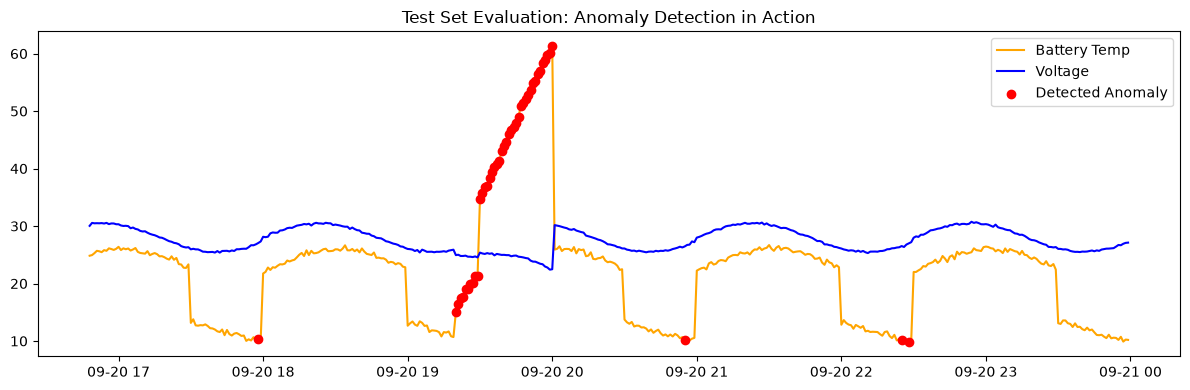

In [8]:
test_scores = model.decision_function(X_test)

# Predict based on our calibrated threshold (1 if score < threshold, else 0)
test_df['Predicted_Anomaly'] = (test_scores < dynamic_threshold).astype(int)

print("\n--- MODEL EVALUATION ON TEST SET ---")
print(classification_report(test_df['Ground_Truth'], test_df['Predicted_Anomaly'], target_names=["Nominal (0)", "Anomaly (1)"]))

print("Confusion Matrix:")
print(confusion_matrix(test_df['Ground_Truth'], test_df['Predicted_Anomaly']))

# Quick visualization of the model catching the test anomaly
plt.figure(figsize=(12, 4))
plt.plot(test_df['Timestamp'], test_df['Temperature_C'], label='Battery Temp', color='orange')
plt.plot(test_df['Timestamp'], test_df['Battery_Voltage_V'], label='Voltage', color='blue')

# Mark predictions
anomalies = test_df[test_df['Predicted_Anomaly'] == 1]
plt.scatter(anomalies['Timestamp'], anomalies['Temperature_C'], color='red', label='Detected Anomaly', zorder=5)

plt.title("Test Set Evaluation: Anomaly Detection in Action")
plt.legend()
plt.tight_layout()
plt.show()

The Interpretation Logic

In [8]:
def generate_interpretation(row):
    """Provides a possible interpretation based on the responsible parameter and severity."""
    if row['Predicted_Anomaly'] == 0:
        return "Nominal operations."

    param = row['Root_Cause_Parameter']
    severity = row['Severity']

    # Interpretation mapping based on parameter and severity
    if param == "Temperature_C":
        if severity == "High":
            return "Critical thermal spike. Possible battery thermal runaway or severe short circuit."
        else:
            return "Elevated thermal limits. Possible minor sensor glitch or temporary compute heat load."

    elif param == "Battery_Voltage_V":
        return "Abnormal voltage drop. Possible battery cell degradation or unmetered parasitic power load."

    elif param == "Power_Consumption_W":
        return "Power draw exceeds nominal bounds. Possible payload latch-up or unexpected component activation."

    elif param == "Solar_Panel_Output_W":
        return "Unexpected solar array drop. Possible micro-meteoroid impact on array, shadowing, or eclipse timing error."

    elif param == "Gyro_Magnitude" or param == "Gyro_Rolling_Std":
        return "Attitude instability (tumbling). Possible ADCS reaction wheel failure or thruster misfire."

    elif param == "Signal_Strength_dBm":
        return "Communication degradation. Possible atmospheric interference, ground station handover failure, or antenna pointing error."

    elif param == "Power_Delta":
        return "Severe power imbalance. Satellite is draining battery faster than solar charge limits."

    else:
        return "Complex multi-system anomaly. Manual telemetry review required."

Thresholding & Severity Scoring

In [11]:
import numpy as np

# 1. Calculate the missing threshold using the Validation set!
val_scores = model.decision_function(X_val)
dynamic_threshold = np.percentile(val_scores, 1.0)

# 2. Have the model make predictions on the test set
test_scores = model.decision_function(X_test)

# 3. Create the missing 'Predicted_Anomaly' column
test_df['Predicted_Anomaly'] = (test_scores < dynamic_threshold).astype(int)

# 4. Create the missing 'Severity' column
test_df['Anomaly_Score'] = -test_scores
score_p98 = np.percentile(test_df['Anomaly_Score'], 98)
score_p90 = np.percentile(test_df['Anomaly_Score'], 90)

def assign_severity(row):
    if row["Predicted_Anomaly"] == 0: return "Nominal"
    if row["Anomaly_Score"] > score_p98: return "High"
    if row["Anomaly_Score"] > score_p90: return "Medium"
    return "Low"

test_df["Severity"] = test_df.apply(assign_severity, axis=1)

print("Predictions and Severity successfully added! You can now run your next cell.")

Predictions and Severity successfully added! You can now run your next cell.


Anomaly Classification & Root Cause Analysis

In [12]:
# Assuming 'test_df' is your dataframe after running the Isolation Forest
# 1. First, ensure you have calculated the Root_Cause_Parameter (using z-scores as shown previously)
means = train_df[features].mean()
stds = train_df[features].std().replace(0, 1e-6)

def find_culprit(row):
    if row["Predicted_Anomaly"] == 0:
        return "None"
    deviations = np.abs((row[features] - means) / stds)
    return deviations.idxmax()

test_df["Root_Cause_Parameter"] = test_df.apply(find_culprit, axis=1)

# 2. Apply the interpretation function
test_df["Possible_Interpretation"] = test_df.apply(generate_interpretation, axis=1)

# 3. Filter to ONLY show the detected anomalies
detected_anomalies = test_df[test_df["Predicted_Anomaly"] == 1].copy()

# 4. Select exactly the columns the assignment asked for
final_classification_table = detected_anomalies[[
    "Timestamp",
    "Root_Cause_Parameter",
    "Anomaly_Score",
    "Severity",
    "Possible_Interpretation"
]]

# Display the result in your Jupyter Notebook
print(final_classification_table.head(10))

               Timestamp Root_Cause_Parameter  Anomaly_Score Severity  \
2518 2026-09-20 17:58:00  Power_Consumption_W       0.010706   Medium   
2600 2026-09-20 19:20:00  Power_Consumption_W       0.050308   Medium   
2601 2026-09-20 19:21:00  Power_Consumption_W       0.049196   Medium   
2602 2026-09-20 19:22:00  Power_Consumption_W       0.060941     High   
2603 2026-09-20 19:23:00  Power_Consumption_W       0.055431   Medium   
2604 2026-09-20 19:24:00  Power_Consumption_W       0.051884   Medium   
2605 2026-09-20 19:25:00  Power_Consumption_W       0.052095   Medium   
2606 2026-09-20 19:26:00  Power_Consumption_W       0.056556   Medium   
2607 2026-09-20 19:27:00  Power_Consumption_W       0.057652   Medium   
2608 2026-09-20 19:28:00  Power_Consumption_W       0.074200     High   

                                Possible_Interpretation  
2518  Power draw exceeds nominal bounds. Possible pa...  
2600  Power draw exceeds nominal bounds. Possible pa...  
2601  Power draw excee